In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection OK")

Connection OK


In [3]:
df = pd.read_sql("""
    SELECT r.id, r.rating, r.sentiment, r.review_text, r.platform,
           a.name as author_name, c.name as category_name
    FROM review r
    JOIN author a ON r.author_id = a.id
    JOIN category c ON r.category_id = c.id
""", engine)

print(df["sentiment"].value_counts())

sentiment
positive    841
negative    159
neutral     100
Name: count, dtype: int64


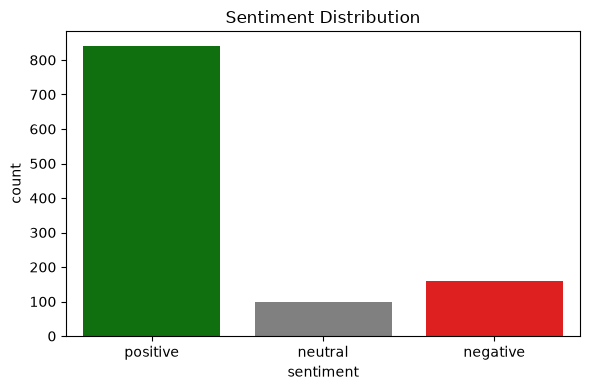

In [4]:
# sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", hue="sentiment",
              palette={"positive": "green", "neutral": "gray", "negative": "red"},
              legend=False)
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

In [5]:
# average rating per sentiment
print(df.groupby("sentiment")["rating"].mean().round(2))

sentiment
negative    2.55
neutral     3.27
positive    4.25
Name: rating, dtype: float64
